In [1]:
import pandas as pd
from prophet import Prophet

df = pd.read_csv('../data/tickers/EVN.AX.csv')
df.head()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-12-01 00:00:00+11:00,3.899193,3.966921,3.850816,3.889518,8840939,0.0,0.0
1,2021-12-02 00:00:00+11:00,3.792764,3.860492,3.725036,3.725036,6483803,0.0,0.0
2,2021-12-03 00:00:00+11:00,3.696009,3.696009,3.604093,3.647632,7223712,0.0,0.0
3,2021-12-06 00:00:00+11:00,3.705685,3.802439,3.705685,3.783088,7102175,0.0,0.0
4,2021-12-07 00:00:00+11:00,3.792764,3.802439,3.744386,3.763737,5851069,0.0,0.0


In [2]:
simple_df = pd.DataFrame()
simple_df['ds'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
simple_df['y'] = df['Close']

In [3]:
m = Prophet()
m.fit(simple_df)

22:10:59 - cmdstanpy - INFO - Chain [1] start processing
22:10:59 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
future = m.make_future_dataframe(periods=28)
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2021-11-30 13:00:00,3.602157,3.339455,3.857945
1,2021-12-01 13:00:00,3.619638,3.359922,3.881122
2,2021-12-02 13:00:00,3.636698,3.372187,3.898338
3,2021-12-05 13:00:00,3.705728,3.449680,3.954152
4,2021-12-06 13:00:00,3.717070,3.457157,3.971581
...,...,...,...,...
529,2023-12-24 13:00:00,4.637579,4.377969,4.897632
530,2023-12-25 13:00:00,4.642674,4.375721,4.892660
531,2023-12-26 13:00:00,4.656618,4.391212,4.898744
532,2023-12-27 13:00:00,4.662777,4.408258,4.906481


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


(array(19554.58333333), 19720.924301132593)

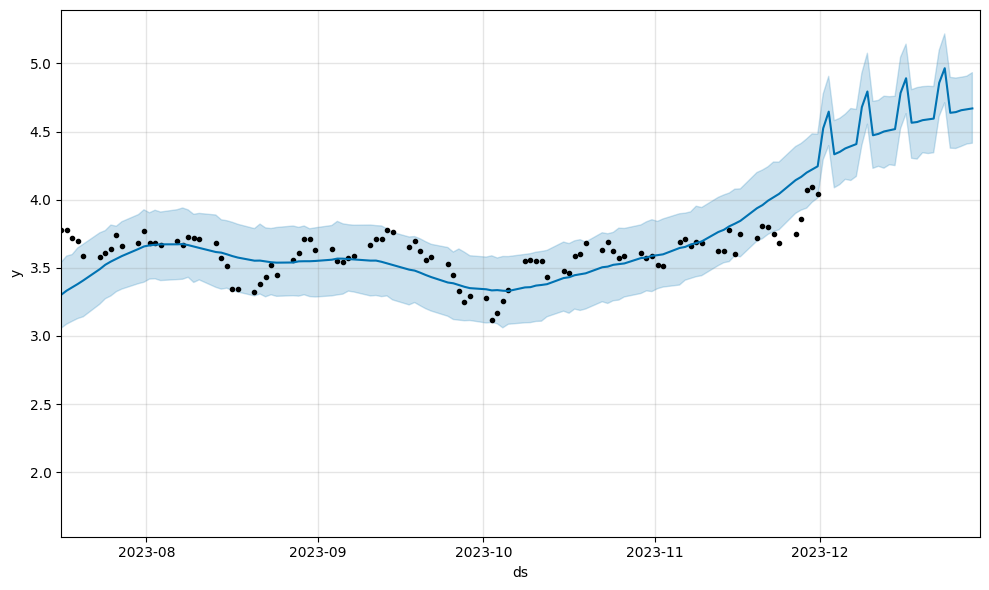

In [5]:
fig1 = m.plot(forecast)
ax = fig1.gca()

ax.set_xlim(simple_df['ds'].take([-100]), pd.to_datetime('now') + pd.DateOffset(days=28))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will

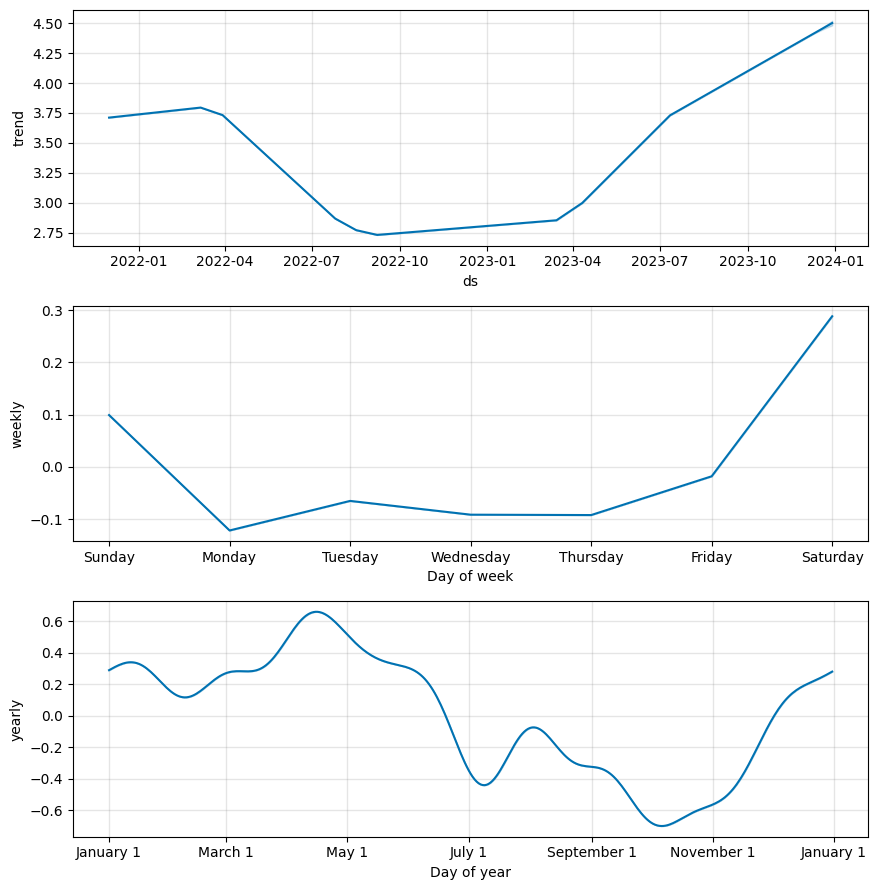

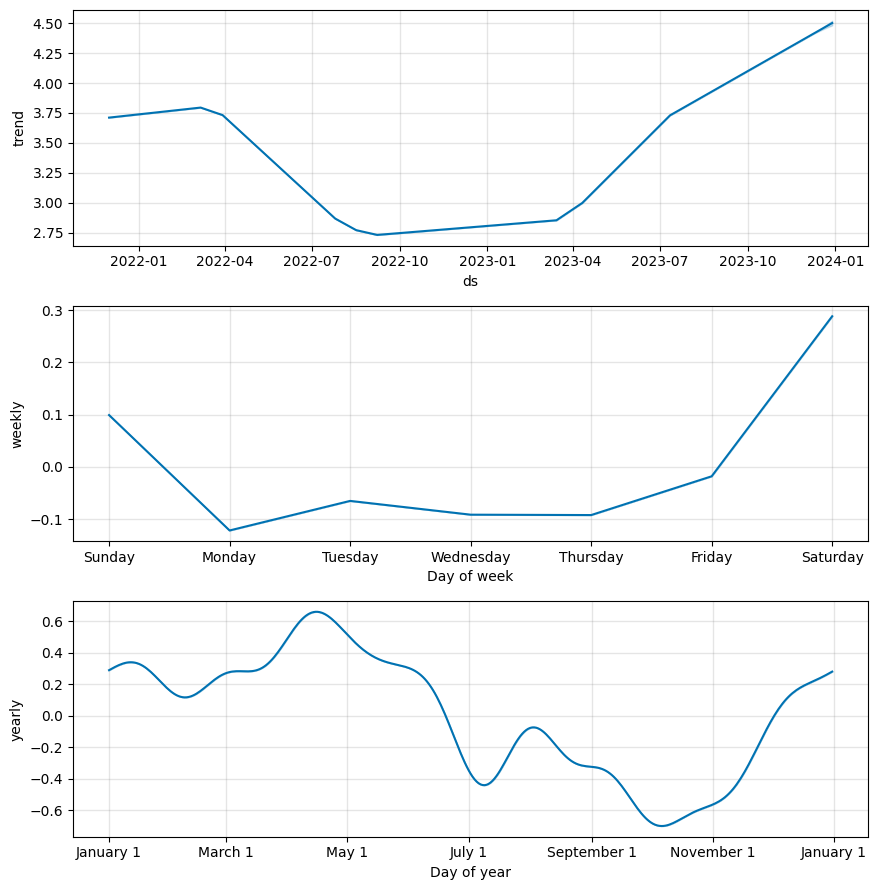

In [6]:
m.plot_components(forecast)